# Two-Stage CNN Pipeline — Evaluation

Recall-focused evaluation on the held-out **test set** (15% of data, never seen during training or threshold selection).

**Report order (per `lecture_eval_meth.md`):**  
1. Recall (primary — minimise false negatives)  
2. Confusion Matrix  
3. ROC / AUC  
4. F1 Score (secondary guard against precision collapse)

> **Crack localisation:** No bounding-box or segmentation annotations exist in `data/`. Crack boxing from image-level labels is not possible and no synthetic boxes are drawn. Section 5 shows **Grad-CAM attention heatmaps** as a non-localization exploratory visualisation — these show where the model attends, not ground-truth crack locations.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import matplotlib.cm as cm_module
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
)
import json, warnings
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)

TensorFlow: 2.16.2


## 1. Load Models, Thresholds & Splits

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
STRUCTURES = ['Decks', 'Pavements', 'Walls']
AUTOTUNE = tf.data.AUTOTUNE

# Load models
structure_model = tf.keras.models.load_model('structure_model.keras')
defect_models = {
    struct: tf.keras.models.load_model(f'defect_model_{struct.lower()}.keras')
    for struct in STRUCTURES
}

# Load tuned thresholds (from training val sweep)
with open('thresholds.json') as f:
    thresholds = json.load(f)
print('Thresholds:', thresholds)

# Load test/val splits (written by pipeline_train.ipynb)
df_test = pd.read_csv('test_split.csv')
df_val  = pd.read_csv('val_split.csv')
print(f'Test set: {len(df_test):,} images')
print(df_test.groupby(['structure', 'label']).size().unstack(fill_value=0))

2026-04-24 12:45:11.759370: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-04-24 12:45:11.759405: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-24 12:45:11.759412: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-24 12:45:11.759427: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-24 12:45:11.759437: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Thresholds: {'Decks': 0.25, 'Pavements': 0.5, 'Walls': 0.5}
Test set: 8,740 images
label      defect  no_defect
structure                   
Decks         317       1951
Pavements     381       3319
Walls         641       2131


## 2. Dataset Helper

In [3]:
def make_dataset(df_rows, label_col, shuffle=False):
    paths  = df_rows['path'].values
    labels = df_rows[label_col].values.astype(np.int32)

    def load_image(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(raw, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

## 3. Stage 1 Evaluation — Structure Classifier

2026-04-24 12:45:15.952727: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


274/274 ━━━━━━━━━━━━━━━━━━━━ 35s 116ms/step
Structure classifier  test accuracy: 0.970

  Decks: recall=0.968
  Pavements: recall=0.965
  Walls: recall=0.979


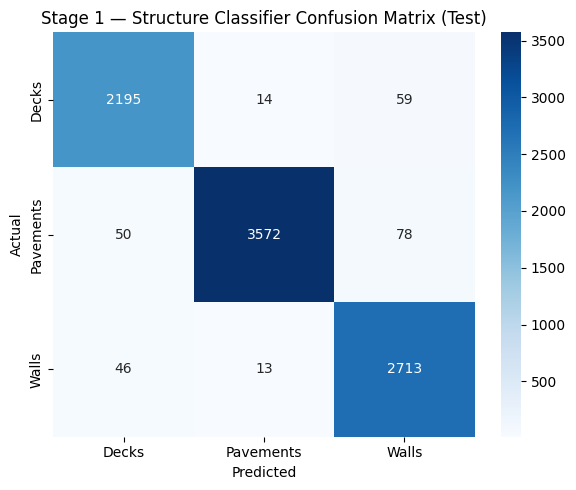

In [4]:
s1_ds = make_dataset(df_test, 'structure_idx')
s1_probs = structure_model.predict(s1_ds, verbose=1)
s1_preds = np.argmax(s1_probs, axis=1)
s1_true  = df_test['structure_idx'].values

cm_s1 = confusion_matrix(s1_true, s1_preds)
acc_s1 = (s1_preds == s1_true).mean()
per_class_recall = cm_s1.diagonal() / cm_s1.sum(axis=1)

print(f'Structure classifier  test accuracy: {acc_s1:.3f}')
print()
for i, struct in enumerate(STRUCTURES):
    print(f'  {struct}: recall={per_class_recall[i]:.3f}')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_s1, annot=True, fmt='d', cmap='Blues',
    xticklabels=STRUCTURES, yticklabels=STRUCTURES,
)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Stage 1 — Structure Classifier Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

## 4. Stage 2 Evaluation — Per-Structure Defect Models

Using tuned thresholds from `thresholds.json`. Primary metric: **recall**.

--- Decks (threshold=0.25) ---
  Recall   : 0.757   ← PRIMARY
  Precision: 0.473
  F1       : 0.583
  ROC-AUC  : 0.890
  Confusion matrix (TN FP / FN TP):
    [1684  267]  (TN=1684, FP=267)
    [ 77 240]  (FN=77, TP=240)  ← minimise FN



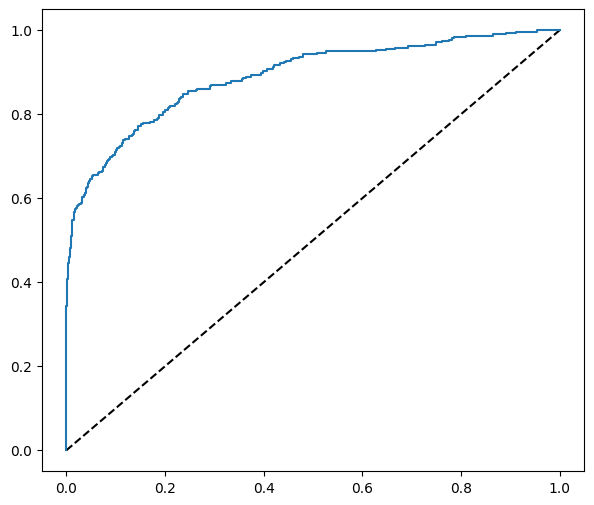

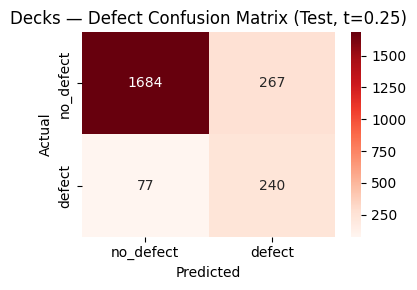

--- Pavements (threshold=0.5) ---
  Recall   : 0.774   ← PRIMARY
  Precision: 0.323
  F1       : 0.456
  ROC-AUC  : 0.873
  Confusion matrix (TN FP / FN TP):
    [2701  618]  (TN=2701, FP=618)
    [ 86 295]  (FN=86, TP=295)  ← minimise FN



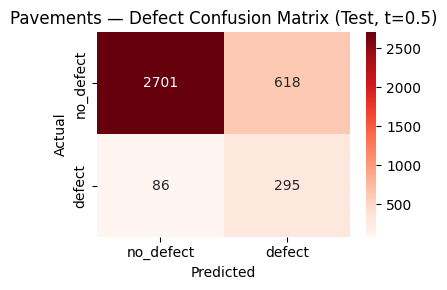

--- Walls (threshold=0.5) ---
  Recall   : 0.897   ← PRIMARY
  Precision: 0.370
  F1       : 0.524
  ROC-AUC  : 0.877
  Confusion matrix (TN FP / FN TP):
    [1152  979]  (TN=1152, FP=979)
    [ 66 575]  (FN=66, TP=575)  ← minimise FN



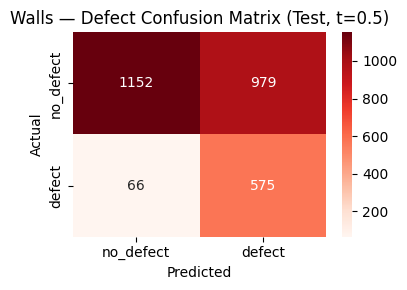

<Figure size 640x480 with 0 Axes>

In [5]:
results = {}  # struct -> dict of metrics

fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')

for struct in STRUCTURES:
    df_st = df_test[df_test['structure'] == struct].reset_index(drop=True)
    model = defect_models[struct]
    thresh = thresholds[struct]

    ds = make_dataset(df_st, 'defect_idx')
    probs  = model.predict(ds, verbose=0).ravel()
    y_true = df_st['defect_idx'].values
    y_pred = (probs >= thresh).astype(int)

    rec   = recall_score(y_true, y_pred, zero_division=0)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    auc   = roc_auc_score(y_true, probs)
    cm    = confusion_matrix(y_true, y_pred)

    results[struct] = {
        'recall': rec, 'precision': prec, 'f1': f1, 'roc_auc': auc,
        'confusion_matrix': cm.tolist(),
        'threshold': thresh,
        'probs': probs, 'y_true': y_true, 'y_pred': y_pred,
    }

    fpr, tpr, _ = roc_curve(y_true, probs)
    ax_roc.plot(fpr, tpr, label=f'{struct} (AUC={auc:.3f})')

    print(f'--- {struct} (threshold={thresh}) ---')
    print(f'  Recall   : {rec:.3f}   ← PRIMARY')
    print(f'  Precision: {prec:.3f}')
    print(f'  F1       : {f1:.3f}')
    print(f'  ROC-AUC  : {auc:.3f}')
    print(f'  Confusion matrix (TN FP / FN TP):')
    print(f'    {cm[0]}  (TN={cm[0,0]}, FP={cm[0,1]})')
    print(f'    {cm[1]}  (FN={cm[1,0]}, TP={cm[1,1]})  ← minimise FN')
    print()

    # Per-structure confusion matrix plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Reds',
        xticklabels=['no_defect', 'defect'],
        yticklabels=['no_defect', 'defect'],
    )
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.title(f'{struct} — Defect Confusion Matrix (Test, t={thresh})')
    plt.tight_layout(); plt.show()

ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate (Recall)')
ax_roc.set_title('ROC Curves — Defect Classifiers (Test Set)')
ax_roc.legend(loc='lower right')
ax_roc.grid(True)
plt.tight_layout(); plt.show()

## 5. End-to-End Pipeline Evaluation

Simulates the full two-stage pipeline on the test set:
1. Structure model predicts the structure type.
2. Predicted structure routes to the matching defect model.
3. Tuned threshold applied → defect / no_defect prediction.

Compare against **oracle-structure recall** (using ground-truth structure label) to measure how Stage 1 errors propagate.

In [6]:
# Predict structure for all test images
s1_probs_test = structure_model.predict(make_dataset(df_test, 'structure_idx'), verbose=1)
pred_struct_idx = np.argmax(s1_probs_test, axis=1)
pred_struct = [STRUCTURES[i] for i in pred_struct_idx]

df_test_e2e = df_test.copy()
df_test_e2e['pred_structure'] = pred_struct

# For each image, get defect probability from the predicted structure's model
e2e_probs  = np.zeros(len(df_test_e2e))
e2e_preds  = np.zeros(len(df_test_e2e), dtype=int)

for struct in STRUCTURES:
    mask = df_test_e2e['pred_structure'] == struct
    if mask.sum() == 0:
        continue
    df_sub = df_test_e2e[mask].reset_index(drop=True)
    model  = defect_models[struct]
    thresh = thresholds[struct]
    ds_sub = make_dataset(df_sub, 'defect_idx')
    probs_sub = model.predict(ds_sub, verbose=0).ravel()
    idx = df_test_e2e.index[mask]
    e2e_probs[idx] = probs_sub
    e2e_preds[idx] = (probs_sub >= thresh).astype(int)

y_true_all = df_test_e2e['defect_idx'].values

e2e_recall = recall_score(y_true_all, e2e_preds, zero_division=0)
e2e_prec   = precision_score(y_true_all, e2e_preds, zero_division=0)
e2e_f1     = f1_score(y_true_all, e2e_preds, zero_division=0)
e2e_auc    = roc_auc_score(y_true_all, e2e_probs)
e2e_cm     = confusion_matrix(y_true_all, e2e_preds)

print('=== End-to-End Pipeline (predicted structure routing) ===')
print(f'  Recall   : {e2e_recall:.3f}   ← PRIMARY')
print(f'  Precision: {e2e_prec:.3f}')
print(f'  F1       : {e2e_f1:.3f}')
print(f'  ROC-AUC  : {e2e_auc:.3f}')
print(f'  Confusion matrix:')
print(f'    TN={e2e_cm[0,0]}, FP={e2e_cm[0,1]}')
print(f'    FN={e2e_cm[1,0]}, TP={e2e_cm[1,1]}  ← minimise FN')

# Oracle recall (use true structure to route)
oracle_probs = np.zeros(len(df_test))
oracle_preds = np.zeros(len(df_test), dtype=int)
for struct in STRUCTURES:
    mask = df_test['structure'] == struct
    if mask.sum() == 0:
        continue
    df_sub  = df_test[mask].reset_index(drop=True)
    model   = defect_models[struct]
    thresh  = thresholds[struct]
    ds_sub  = make_dataset(df_sub, 'defect_idx')
    probs_sub = model.predict(ds_sub, verbose=0).ravel()
    idx = df_test.index[mask]
    oracle_probs[idx] = probs_sub
    oracle_preds[idx] = (probs_sub >= thresh).astype(int)

oracle_recall = recall_score(df_test['defect_idx'].values, oracle_preds, zero_division=0)
print(f'\n  Oracle recall (true structure routing): {oracle_recall:.3f}')
print(f'  E2E recall   (predicted structure)    : {e2e_recall:.3f}')
recall_drop = oracle_recall - e2e_recall
print(f'  Recall drop from Stage 1 errors       : {recall_drop:.3f}')

274/274 ━━━━━━━━━━━━━━━━━━━━ 33s 117ms/step
=== End-to-End Pipeline (predicted structure routing) ===
  Recall   : 0.834   ← PRIMARY
  Precision: 0.370
  F1       : 0.513
  ROC-AUC  : 0.882
  Confusion matrix:
    TN=5503, FP=1898
    FN=222, TP=1117  ← minimise FN

  Oracle recall (true structure routing): 0.829
  E2E recall   (predicted structure)    : 0.834
  Recall drop from Stage 1 errors       : -0.005


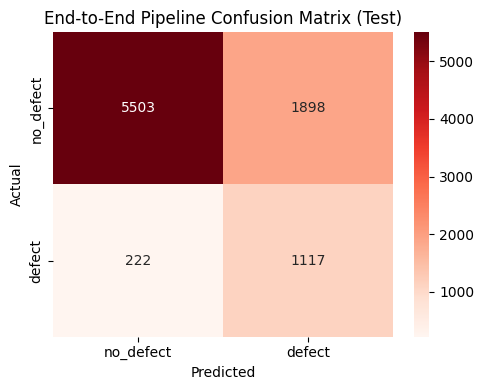

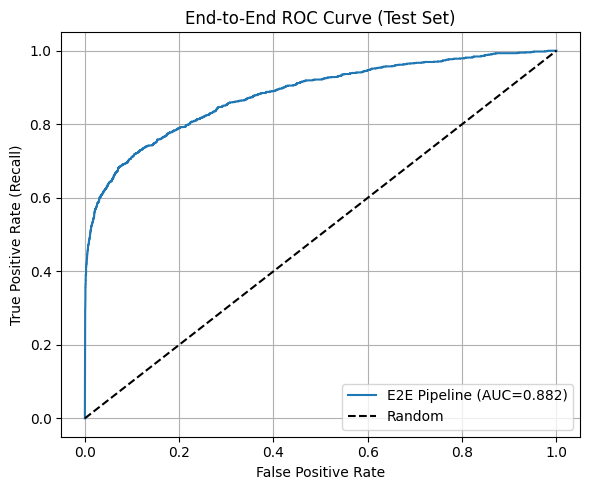

In [7]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    e2e_cm, annot=True, fmt='d', cmap='Reds',
    xticklabels=['no_defect', 'defect'],
    yticklabels=['no_defect', 'defect'],
)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('End-to-End Pipeline Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

fpr_e2e, tpr_e2e, _ = roc_curve(y_true_all, e2e_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr_e2e, tpr_e2e, label=f'E2E Pipeline (AUC={e2e_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('End-to-End ROC Curve (Test Set)')
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

## 6. Grad-CAM Attention Heatmaps

> **Important:** These are model attention visualisations, not ground-truth crack localisations. The dataset has no bounding-box or segmentation annotations. These heatmaps show which image regions the defect model weighted most heavily — useful for sanity-checking model focus, but **cannot substitute for annotated localization labels**.

Displayed for a sample of true-positive defect predictions from each structure.

Grad-CAM heatmaps — true positive defect samples (model attention, not crack labels)

  Grad-CAM failed for data/Decks/defect/7004-60.jpg: Output with path `0` is not connected to `inputs`
  Grad-CAM failed for data/Decks/defect/7004-126.jpg: Output with path `0` is not connected to `inputs`
  Grad-CAM failed for data/Decks/defect/7018-121.jpg: Output with path `0` is not connected to `inputs`


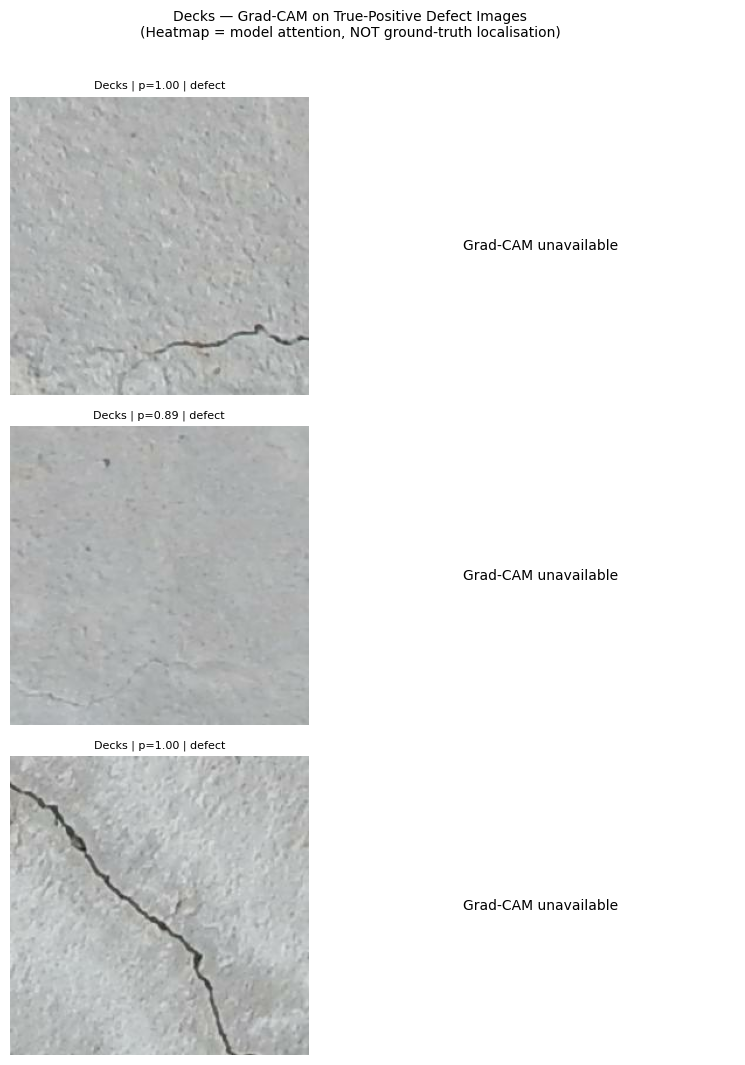

  Grad-CAM failed for data/Pavements/defect/103-158.jpg: Output with path `0` is not connected to `inputs`
  Grad-CAM failed for data/Pavements/defect/067-79.jpg: Output with path `0` is not connected to `inputs`
  Grad-CAM failed for data/Pavements/defect/036-81.jpg: Output with path `0` is not connected to `inputs`


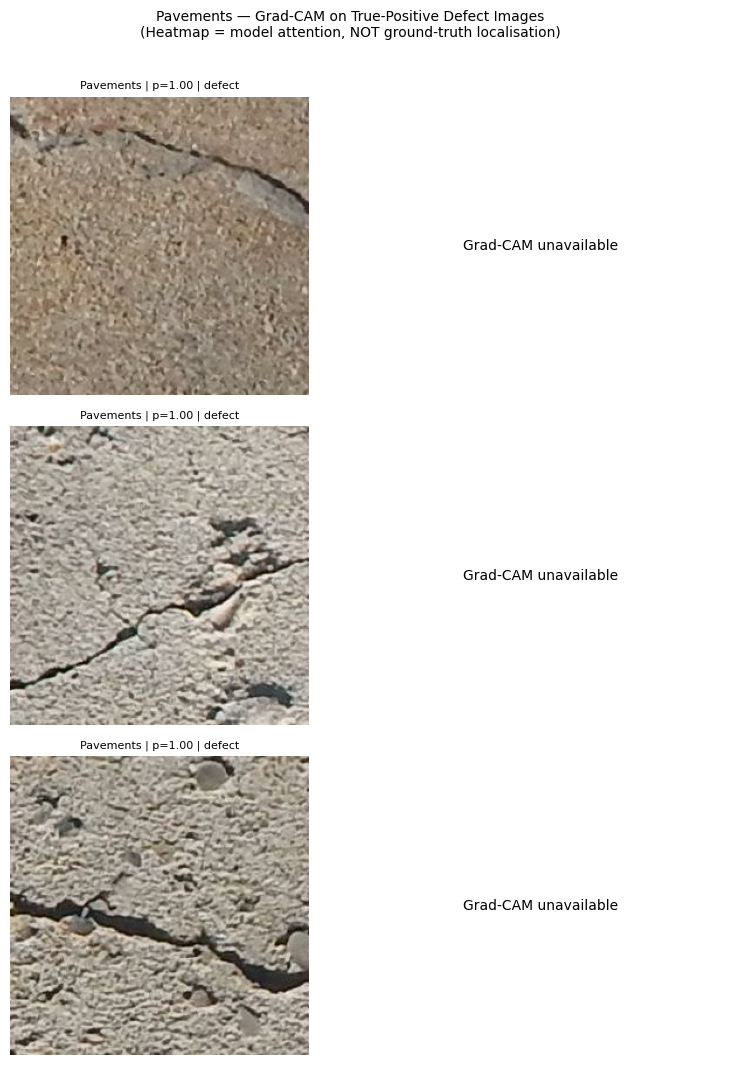

  Grad-CAM failed for data/Walls/defect/7079-196.jpg: Output with path `0` is not connected to `inputs`
  Grad-CAM failed for data/Walls/defect/7073-229.jpg: Output with path `0` is not connected to `inputs`
  Grad-CAM failed for data/Walls/defect/7087-115.jpg: Output with path `0` is not connected to `inputs`


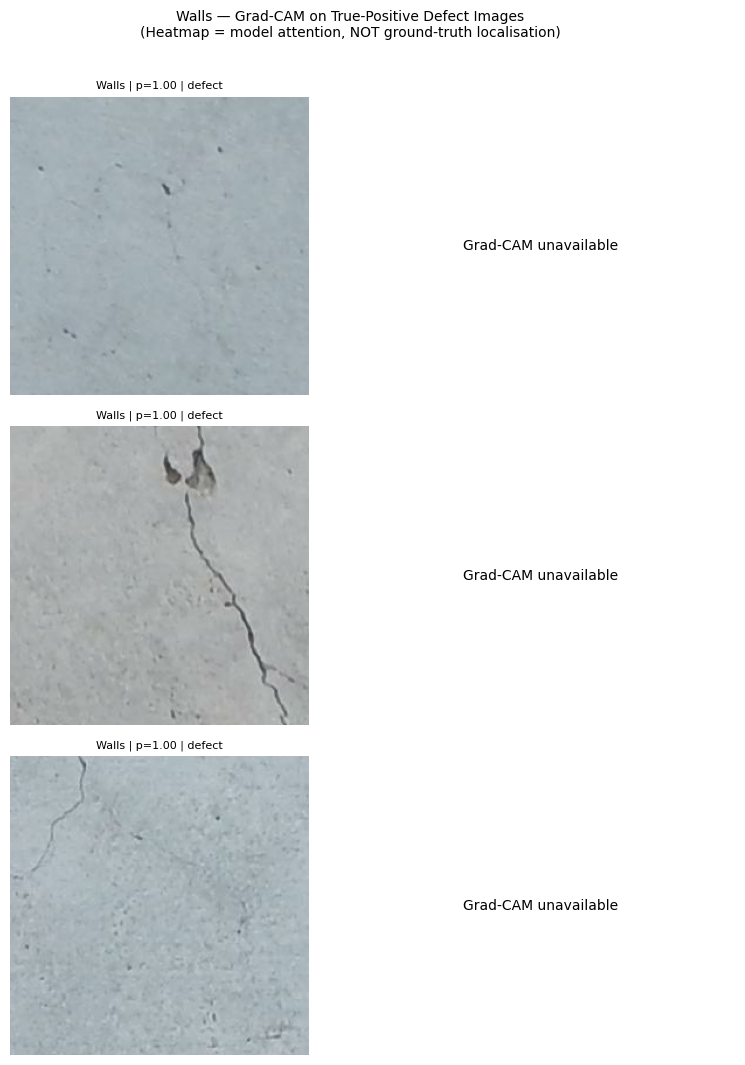

In [8]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name='Conv_1'):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def show_gradcam(img_path, model, struct_name, thresh, ax_row):
    raw = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img_resized = tf.image.resize(img, IMG_SIZE)
    img_array = tf.expand_dims(tf.cast(img_resized, tf.float32), 0)

    prob = float(model.predict(img_array, verbose=0)[0][0])
    pred = 'defect' if prob >= thresh else 'no_defect'

    # Find last conv layer in MobileNetV2
    last_conv = None
    for layer in reversed(model.layers):
        if hasattr(layer, 'layers'):  # nested model
            for sub in reversed(layer.layers):
                if isinstance(sub, tf.keras.layers.Conv2D):
                    last_conv = sub.name
                    break
        if last_conv:
            break

    try:
        # Build sub-model through the backbone
        backbone = None
        for layer in model.layers:
            if hasattr(layer, 'layers') and len(layer.layers) > 10:
                backbone = layer
                break
        if backbone is None:
            raise ValueError('backbone not found')

        grad_model = Model(
            inputs=model.input,
            outputs=[backbone.get_layer(last_conv).output, model.output],
        )
        with tf.GradientTape() as tape:
            conv_outs, preds = grad_model(img_array)
            loss = preds[:, 0]
        grads = tape.gradient(loss, conv_outs)
        pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap = conv_outs[0] @ pooled[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
        heatmap = heatmap.numpy()
    except Exception as e:
        heatmap = None
        print(f'  Grad-CAM failed for {img_path}: {e}')

    orig = img.numpy().astype(np.uint8)
    ax_row[0].imshow(orig); ax_row[0].axis('off')
    ax_row[0].set_title(f'{struct_name} | p={prob:.2f} | {pred}', fontsize=8)

    if heatmap is not None:
        hm_resized = tf.image.resize(
            heatmap[..., np.newaxis], (orig.shape[0], orig.shape[1])
        ).numpy()[..., 0]
        colored = cm_module.jet(hm_resized)[..., :3]
        overlay = (0.6 * orig / 255.0 + 0.4 * colored)
        overlay = np.clip(overlay, 0, 1)
        ax_row[1].imshow(overlay); ax_row[1].axis('off')
        ax_row[1].set_title('Grad-CAM (model attention)', fontsize=8)
    else:
        ax_row[1].text(0.5, 0.5, 'Grad-CAM unavailable',
                       ha='center', va='center', transform=ax_row[1].transAxes)
        ax_row[1].axis('off')


print('Grad-CAM heatmaps — true positive defect samples (model attention, not crack labels)\n')
N_SAMPLES = 3

for struct in STRUCTURES:
    # Select true-positive images from oracle predictions
    mask_arr = (df_test['structure'] == struct).values & (df_test['defect_idx'] == 1).values
    df_tp = df_test[mask_arr & (oracle_preds == 1)].reset_index(drop=True)

    if len(df_tp) == 0:
        print(f'{struct}: no true positives found in test set.')
        continue

    sample = df_tp.sample(min(N_SAMPLES, len(df_tp)), random_state=SEED)
    fig, axes = plt.subplots(len(sample), 2, figsize=(8, 3.5 * len(sample)))
    if len(sample) == 1:
        axes = [axes]
    fig.suptitle(f'{struct} — Grad-CAM on True-Positive Defect Images\n'
                 '(Heatmap = model attention, NOT ground-truth localisation)',
                 fontsize=10, y=1.01)

    for ax_row, (_, row) in zip(axes, sample.iterrows()):
        show_gradcam(
            row['path'], defect_models[struct],
            struct, thresholds[struct], ax_row,
        )

    plt.tight_layout(); plt.show()

## 7. Summary Report

In [9]:
summary_rows = []
for struct in STRUCTURES:
    r = results[struct]
    cm = np.array(r['confusion_matrix'])
    summary_rows.append({
        'Structure': struct,
        'Threshold': r['threshold'],
        'Recall': round(r['recall'], 3),
        'Precision': round(r['precision'], 3),
        'F1': round(r['f1'], 3),
        'ROC-AUC': round(r['roc_auc'], 3),
        'TN': int(cm[0, 0]), 'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]), 'TP': int(cm[1, 1]),
    })

df_summary = pd.DataFrame(summary_rows)
print('=== Per-Structure Defect Model Results (Oracle Routing) ===')
print(df_summary.to_string(index=False))
print()
print('=== End-to-End Pipeline (Predicted Structure Routing) ===')
print(f'  Recall   : {e2e_recall:.3f}')
print(f'  Precision: {e2e_prec:.3f}')
print(f'  F1       : {e2e_f1:.3f}')
print(f'  ROC-AUC  : {e2e_auc:.3f}')
print(f'  FN (missed defects): {e2e_cm[1,0]}')

=== Per-Structure Defect Model Results (Oracle Routing) ===
Structure  Threshold  Recall  Precision    F1  ROC-AUC   TN  FP  FN  TP
    Decks       0.25   0.757      0.473 0.583    0.890 1684 267  77 240
Pavements       0.50   0.774      0.323 0.456    0.873 2701 618  86 295
    Walls       0.50   0.897      0.370 0.524    0.877 1152 979  66 575

=== End-to-End Pipeline (Predicted Structure Routing) ===
  Recall   : 0.834
  Precision: 0.370
  F1       : 0.513
  ROC-AUC  : 0.882
  FN (missed defects): 222


In [10]:
# Write pipeline_report.md
report_lines = [
    '# Pipeline Report — Two-Stage CNN (Structure → Defect)',
    '',
    '## Assumptions & Limitations',
    '',
    '- Dataset contains **image-level labels only** (no bounding boxes, masks, or polygons).',
    '- **Crack bounding-box localisation is not supported by the available labels.** No synthetic boxes are drawn.',
    '- Grad-CAM heatmaps in `pipeline_eval.ipynb` show model attention, not ground-truth crack locations.',
    '- Grouped train/val/test split by `sceneID` filename prefix to reduce near-duplicate leakage.',
    '- Class imbalance (10–21% defect) handled via `class_weight` + threshold tuning.',
    '- Pretrained MobileNetV2 (ImageNet); last 20 layers fine-tuned per structure.',
    '- Recall prioritised over precision per `lecture_eval_meth.md`.',
    '',
    '## Data Split',
    '',
    '| Split | Images |',
    '|-------|--------|',
]  + [
    f'| Train | {len(pd.read_csv("train_split.csv")):,} |',
    f'| Val   | {len(df_val):,} |',
    f'| Test  | {len(df_test):,} |',
] + [
    '',
    '## Stage 1 — Structure Classifier',
    '',
    f'- Test accuracy: **{acc_s1:.3f}**',
    '',
    '## Stage 2 — Per-Structure Defect Models (Oracle Routing)',
    '',
    '| Structure | Threshold | Recall | Precision | F1 | ROC-AUC | FN |',
    '|-----------|-----------|--------|-----------|----|---------|----|',
] + [
    f'| {r["Structure"]} | {r["Threshold"]} | **{r["Recall"]}** | {r["Precision"]} | {r["F1"]} | {r["ROC-AUC"]} | {r["FN"]} |'
    for r in summary_rows
] + [
    '',
    '## End-to-End Pipeline (Predicted Structure Routing)',
    '',
    f'| Metric | Value |',
    f'|--------|-------|',
    f'| Recall | **{e2e_recall:.3f}** |',
    f'| Precision | {e2e_prec:.3f} |',
    f'| F1 | {e2e_f1:.3f} |',
    f'| ROC-AUC | {e2e_auc:.3f} |',
    f'| FN (missed defects) | {e2e_cm[1,0]} |',
    f'| Oracle Recall | {oracle_recall:.3f} |',
    f'| Recall drop from Stage 1 errors | {oracle_recall - e2e_recall:.3f} |',
    '',
    '## Tuned Thresholds',
    '',
] + [
    f'- {struct}: {thresholds[struct]}'
    for struct in STRUCTURES
] + [
    '',
    '---',
    '_Generated by `pipeline_eval.ipynb`_',
]

with open('pipeline_report.md', 'w') as f:
    f.write('\n'.join(report_lines) + '\n')

print('Saved pipeline_report.md')

Saved pipeline_report.md
